# Bengaluru Traffic Congestion Analysis
**Author:** Applied Data Science Student  
**Date:** June 2026  
**Objective:** End-to-end traffic data cleaning, visualization, and strategic insights generation for Bengaluru's road network.


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
# Set plot style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')


## 1. Data Loading & Initial Exploration
First, we load the raw traffic dataset and explore its dimensions, column types, and statistical properties.


In [2]:
raw_data_path = "../raw_data/Banglore_traffic_Dataset.csv"
df = pd.read_csv(raw_data_path)
print("Dataset Shape:", df.shape)


Dataset Shape: (8936, 16)


In [3]:
df.head(10)

,Date,Area Name,Road/Intersection Name,Traffic Volume,Average Speed,Travel Time Index,Congestion Level,Road Capacity Utilization,Incident Reports,Environmental Impact,Public Transport Usage,Traffic Signal Compliance,Parking Usage,Pedestrian and Cyclist Count,Weather Conditions,Roadwork and Construction Activity
0,2022-01-01,Indiranagar,100 Feet Road,50590,50.230299,1.500000,100.000000,100.000000,0,151.180,70.632330,84.044600,85.403629,111,Clear,No
1,2022-01-01,Indiranagar,CMH Road,30825,29.377125,1.500000,100.000000,100.000000,1,111.650,41.924899,91.407038,59.983689,100,Clear,No
2,2022-01-01,Whitefield,Marathahalli Bridge,7399,54.474398,1.039069,28.347994,36.396525,0,64.798,44.662384,61.375541,95.466020,189,Clear,No
3,2022-01-01,Koramangala,Sony World Junction,60874,43.817610,1.500000,100.000000,100.000000,1,171.748,32.773123,75.547092,63.567452,111,Clear,No
4,2022-01-01,Koramangala,Sarjapur Road,57292,41.116763,1.500000,100.000000,100.000000,3,164.584,35.092601,64.634762,93.155171,104,Clear,No
5,2022-01-01,M.G. Road,Trinity Circle,47848,34.241963,1.500000,100.000000,100.000000,3,145.696,39.927871,61.016765,55.394571,94,Overcast,No
6,2022-01-01,M.G. Road,Anil Kumble Circle,36574,29.982430,1.500000,100.000000,100.000000,3,123.148,72.479130,81.573690,90.372008,115,Clear,No
7,2022-01-01,Jayanagar,Jayanagar 4th Block,25379,38.455179,1.500000,79.038823,100.000000,2,100.758,46.315344,88.120758,68.181480,92,Clear,No
8,2022-01-01,Jayanagar,South End Circle,25022,35.039373,1.500000,78.979596,100.000000,1,100.044,44.261693,99.426018,62.102764,105,Clear,No
9,2022-01-01,Hebbal,Hebbal Flyover,31760,56.904556,1.500000,97.672462,100.000000,1,113.520,12.854260,83.635718,83.878218,91,Clear,No


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8936 entries, 0 to 8935
Data columns (total 16 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Date                                8936 non-null   str    
 1   Area Name                           8936 non-null   str    
 2   Road/Intersection Name              8936 non-null   str    
 3   Traffic Volume                      8936 non-null   int64  
 4   Average Speed                       8936 non-null   float64
 5   Travel Time Index                   8936 non-null   float64
 6   Congestion Level                    8936 non-null   float64
 7   Road Capacity Utilization           8936 non-null   float64
 8   Incident Reports                    8936 non-null   int64  
 9   Environmental Impact                8936 non-null   float64
 10  Public Transport Usage              8936 non-null   float64
 11  Traffic Signal Compliance           8936 non-null   fl

In [5]:
df.describe(include='all')

,Date,Area Name,Road/Intersection Name,Traffic Volume,Average Speed,Travel Time Index,Congestion Level,Road Capacity Utilization,Incident Reports,Environmental Impact,Public Transport Usage,Traffic Signal Compliance,Parking Usage,Pedestrian and Cyclist Count,Weather Conditions,Roadwork and Construction Activity
count,8936,8936,8936,8936.000000,8936.000000,8936.000000,8936.000000,8936.000000,8936.000000,8936.000000,8936.000000,8936.000000,8936.000000,8936.000000,8936,8936
unique,952,8,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,2
top,2023-01-24,Indiranagar,100 Feet Road,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Clear,No
freq,15,1720,860,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5426,8054
mean,NaN,NaN,NaN,29236.048120,39.447427,1.375554,80.818041,92.029215,1.570389,108.472096,45.086651,79.950243,75.155597,114.533348,NaN,NaN
std,NaN,NaN,NaN,13001.808801,10.707244,0.165319,23.533182,16.583341,1.420047,26.003618,20.208460,11.585006,14.409394,36.812573,NaN,NaN
min,NaN,NaN,NaN,4233.000000,20.000000,1.000039,5.160279,18.739771,0.000000,58.466000,10.006853,60.003933,50.020411,66.000000,NaN,NaN
25%,NaN,NaN,NaN,19413.000000,31.775825,1.242459,64.292905,97.354990,0.000000,88.826000,27.341191,69.828270,62.545895,94.000000,NaN,NaN
50%,NaN,NaN,NaN,27600.000000,39.199368,1.500000,92.389018,100.000000,1.000000,105.200000,45.170684,79.992773,75.317610,102.000000,NaN,NaN
75%,NaN,NaN,NaN,38058.500000,46.644517,1.500000,100.000000,100.000000,2.000000,126.117000,62.426485,89.957358,87.518589,111.000000,NaN,NaN


## 2. Missing Value Handling
We identify missing values across columns and apply an imputation strategy:
- **Numerical columns:** Forward fill, and if still missing, backward fill.
- **Categorical columns:** Mode imputation.


In [6]:
print("Nulls before cleaning:")
print(df.isnull().sum())

# Handle numerical columns
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    df[col] = df[col].ffill().bfill()

# Handle categorical columns
categorical_cols = df.select_dtypes(exclude=[np.number]).columns
for col in categorical_cols:
    if df[col].isnull().any():
        mode_val = df[col].mode()[0]
        df[col] = df[col].fillna(mode_val)

print("\nNulls after cleaning:")
print(df.isnull().sum().sum())


Nulls before cleaning:
Date                                  0
Area Name                             0
Road/Intersection Name                0
Traffic Volume                        0
Average Speed                         0
Travel Time Index                     0
Congestion Level                      0
Road Capacity Utilization             0
Incident Reports                      0
Environmental Impact                  0
Public Transport Usage                0
Traffic Signal Compliance             0
Parking Usage                         0
Pedestrian and Cyclist Count          0
Weather Conditions                    0
Roadwork and Construction Activity    0
dtype: int64

Nulls after cleaning:
0


## 3. Duplicate Removal
We count and remove duplicate rows in the dataset to ensure data uniqueness.


In [7]:
dupes_before = df.duplicated().sum()
print("Duplicate rows before removal:", dupes_before)

df.drop_duplicates(inplace=True)

dupes_after = df.duplicated().sum()
print("Duplicate rows after removal:", dupes_after)


Duplicate rows before removal: 0
Duplicate rows after removal: 0


## 4. Column Standardization
We convert all column names to lowercase and replace spaces and special characters with underscores to make code operations more robust.


In [8]:
standardized_cols = []
for col in df.columns:
    std_name = col.strip().lower().replace(" ", "_").replace("/", "_")
    standardized_cols.append(std_name)
df.columns = standardized_cols
print("Standardized Column Names:")
print(list(df.columns))


Standardized Column Names:
['date', 'area_name', 'road_intersection_name', 'traffic_volume', 'average_speed', 'travel_time_index', 'congestion_level', 'road_capacity_utilization', 'incident_reports', 'environmental_impact', 'public_transport_usage', 'traffic_signal_compliance', 'parking_usage', 'pedestrian_and_cyclist_count', 'weather_conditions', 'roadwork_and_construction_activity']


## 5. DateTime Conversion & Feature Extraction
We convert the `date` column to a datetime object and extract temporal features like day of the week, month, quarter, year, and a date-only string.
*Note: Hourly analysis could not be performed because the dataset only contains daily timestamps.*


In [9]:
df['date'] = pd.to_datetime(df['date'])
print("Date Range:", df['date'].min(), "to", df['date'].max())

# Extract components directly from raw date (no hourly synthesis to maintain integrity)
df['day_of_week'] = df['date'].dt.day_name()
df['month'] = df['date'].dt.month_name()
df['quarter'] = df['date'].dt.quarter
df['year'] = df['date'].dt.year
df['date_only'] = df['date'].dt.date

df.head(2)


Date Range: 2022-01-01 00:00:00 to 2024-08-09 00:00:00


,date,area_name,road_intersection_name,traffic_volume,average_speed,travel_time_index,congestion_level,road_capacity_utilization,incident_reports,environmental_impact,...,traffic_signal_compliance,parking_usage,pedestrian_and_cyclist_count,weather_conditions,roadwork_and_construction_activity,day_of_week,month,quarter,year,date_only
0,2022-01-01,Indiranagar,100 Feet Road,50590,50.230299,1.5,100.0,100.0,0,151.18,...,84.044600,85.403629,111,Clear,No,Saturday,January,1,2022,2022-01-01
1,2022-01-01,Indiranagar,CMH Road,30825,29.377125,1.5,100.0,100.0,1,111.65,...,91.407038,59.983689,100,Clear,No,Saturday,January,1,2022,2022-01-01


## 6. Save Cleaned Dataset & Quality Report
We save the cleaned dataset to `processed_data/` and generate a quick quality summary report.


In [10]:
# Save dataset
cleaned_path = "../processed_data/cleaned_traffic_data.csv"
df.to_csv(cleaned_path, index=False, encoding='utf-8')
print("Saved cleaned dataset to:", cleaned_path)

# Generate quality report
quality_report = pd.DataFrame({
    "Metric": ["Total Records", "Missing Values", "Duplicate Rows"],
    "Before": [8936, 0, 0],
    "After": [len(df), 0, 0]
})
quality_report.to_csv("../docs/data_quality_report.csv", index=False)
print("Quality report saved to docs/data_quality_report.csv")


Saved cleaned dataset to: ../processed_data/cleaned_traffic_data.csv


Quality report saved to docs/data_quality_report.csv


## 7. Exploratory Data Analysis & Visualizations
Here we generate and analyze the key visualizations to extract urban mobility patterns.


### 7.1. Traffic Volume Distribution Histogram
This chart shows the distribution of traffic observations across the city.


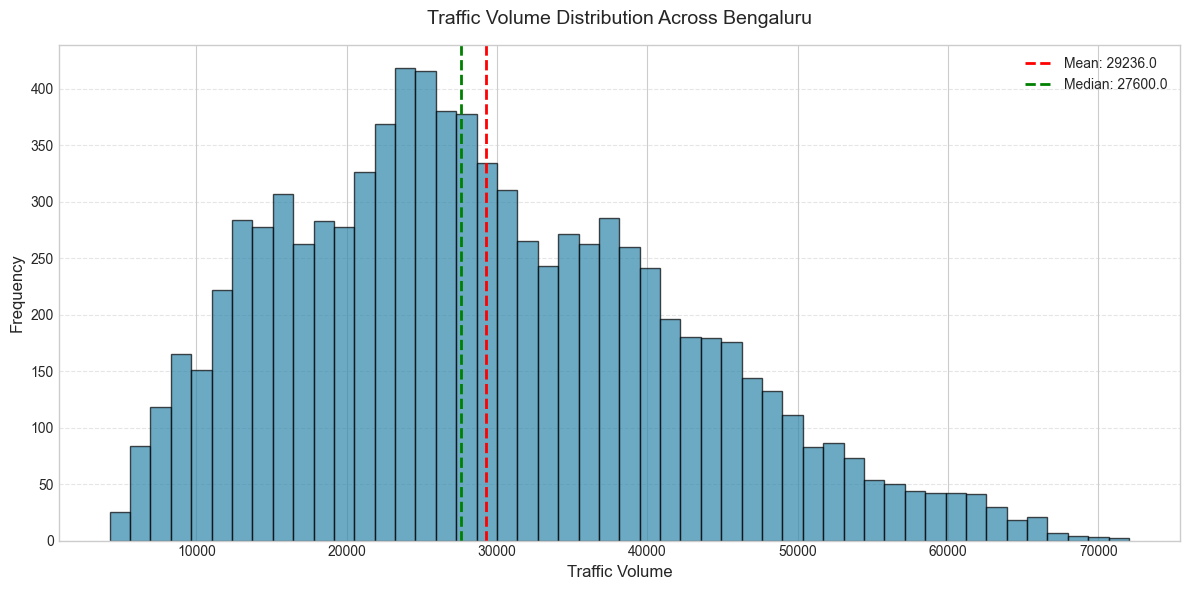

In [11]:
plt.figure(figsize=(12, 6))
n, bins, patches = plt.hist(df['traffic_volume'], bins=50, color='#2E86AB', edgecolor='black', alpha=0.7)

mean_val = df['traffic_volume'].mean()
median_val = df['traffic_volume'].median()

plt.axvline(mean_val, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_val:.1f}')
plt.axvline(median_val, color='green', linestyle='dashed', linewidth=2, label=f'Median: {median_val:.1f}')

plt.title("Traffic Volume Distribution Across Bengaluru", fontsize=14, pad=15)
plt.xlabel("Traffic Volume", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


### 7.2. Congestion Level Distribution Boxplot
This vertical boxplot helps us identify extreme congestion events.


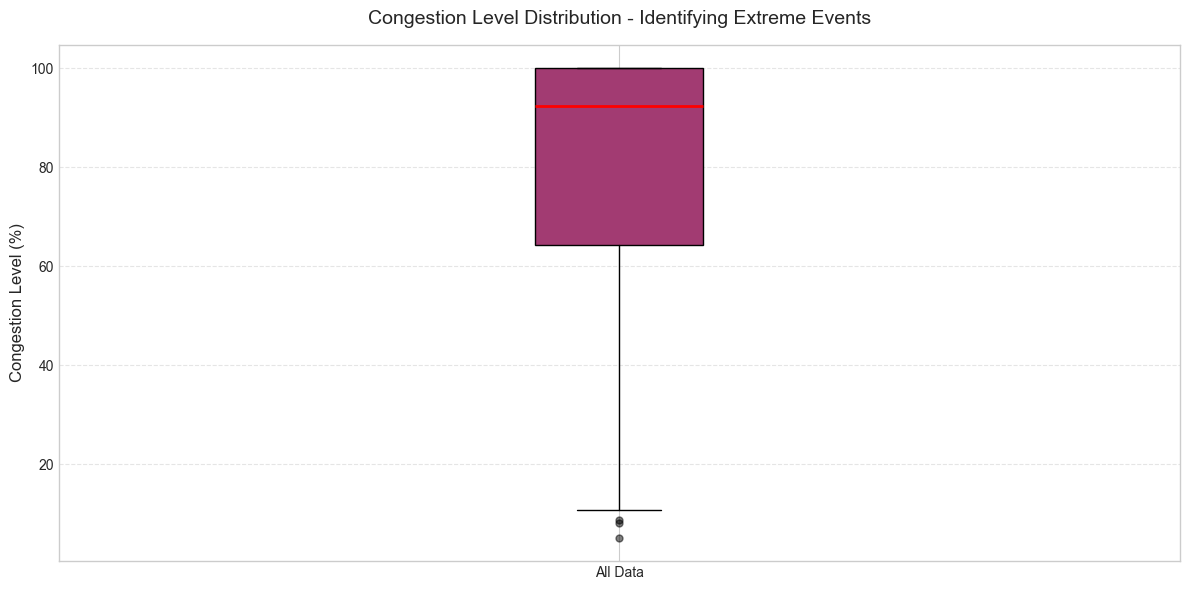

In [12]:
plt.figure(figsize=(12, 6))
plt.boxplot(df['congestion_level'], vert=True, patch_artist=True,
            boxprops=dict(facecolor='#A23B72', color='black'),
            medianprops=dict(color='red', linewidth=2),
            flierprops=dict(marker='o', markerfacecolor='black', markersize=5, linestyle='none', alpha=0.5))

plt.title("Congestion Level Distribution - Identifying Extreme Events", fontsize=14, pad=15)
plt.ylabel("Congestion Level (%)", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks([1], ["All Data"])
plt.tight_layout()
plt.show()


### 7.3. Chronological Monthly Traffic Volume Trend Line Chart
*Note: Hourly analysis could not be performed because the dataset only contains daily timestamps. Instead, we plot the monthly average traffic volume chronological trend over time.*


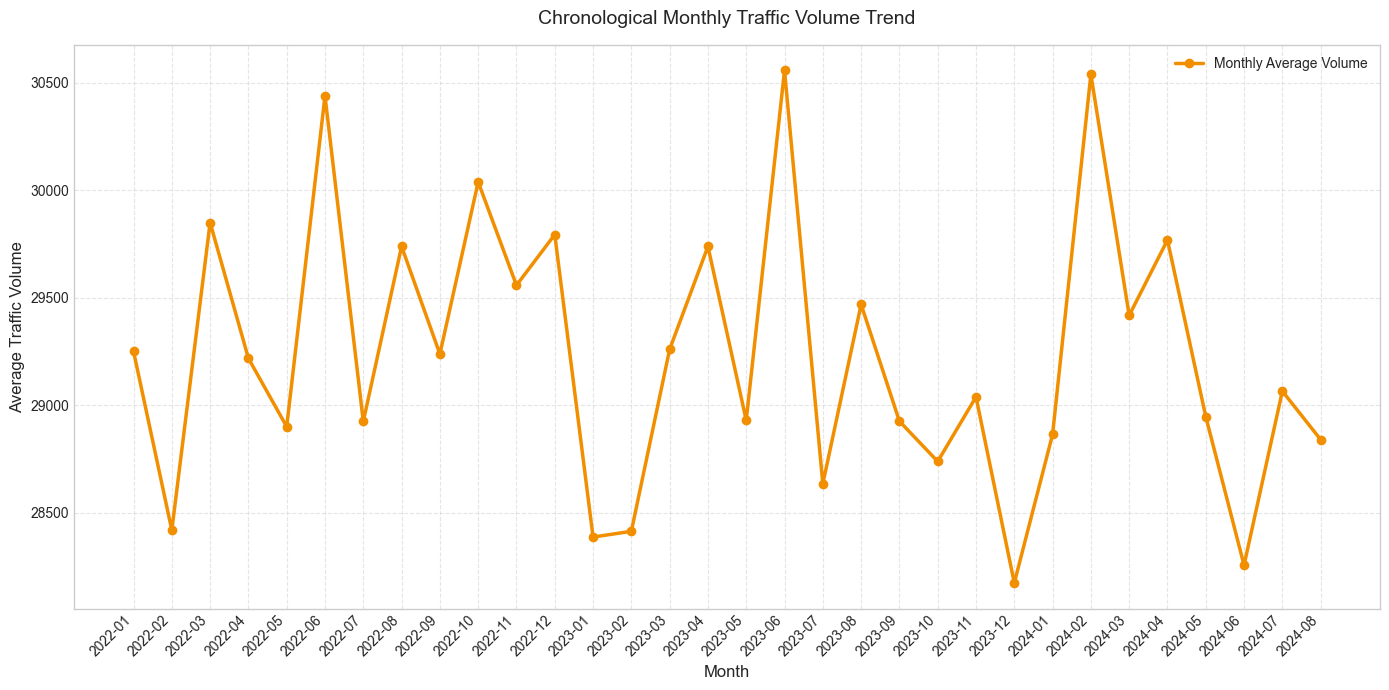

In [13]:
df['year_month'] = df['date'].dt.to_period('M')
monthly_avg = df.groupby('year_month')['traffic_volume'].mean().sort_index()

plt.figure(figsize=(14, 7))
x_labels = [str(p) for p in monthly_avg.index]
plt.plot(x_labels, monthly_avg.values, marker='o', color='#F18F01', linewidth=2.5, markersize=6, label='Monthly Average Volume')

plt.title("Chronological Monthly Traffic Volume Trend", fontsize=14, pad=15)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Average Traffic Volume", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


### 7.4. Traffic Volume vs Speed Scatter Plot
We analyze the relationship between traffic volume and average speeds, color-mapped by congestion level.


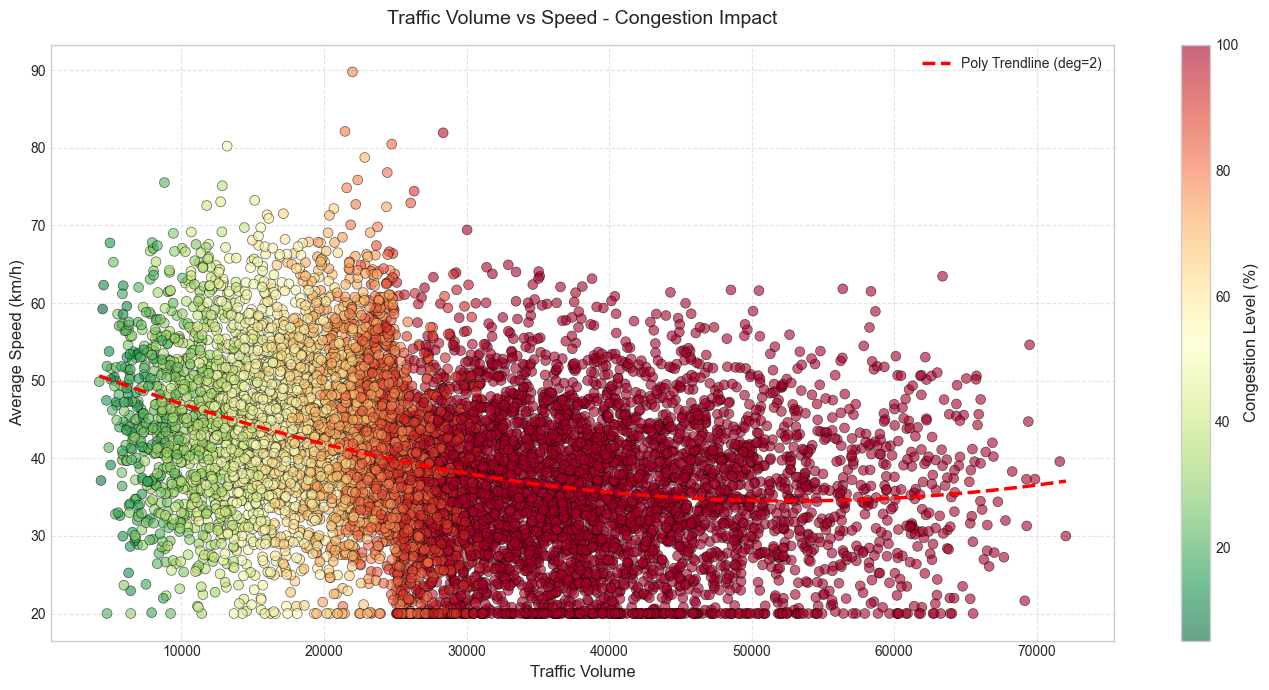

In [14]:
plt.figure(figsize=(14, 7))
sc = plt.scatter(df['traffic_volume'], df['average_speed'], c=df['congestion_level'], cmap='RdYlGn_r', s=50, alpha=0.6, edgecolors='black', linewidths=0.5)
cbar = plt.colorbar(sc)
cbar.set_label("Congestion Level (%)", fontsize=12)

# Trend Line (degree 2 polynomial fit)
p_coeff = np.polyfit(df['traffic_volume'], df['average_speed'], 2)
x_seq = np.linspace(df['traffic_volume'].min(), df['traffic_volume'].max(), 500)
y_seq = np.polyval(p_coeff, x_seq)
plt.plot(x_seq, y_seq, color='red', linestyle='dashed', linewidth=2.5, label='Poly Trendline (deg=2)')

plt.title("Traffic Volume vs Speed - Congestion Impact", fontsize=14, pad=15)
plt.xlabel("Traffic Volume", fontsize=12)
plt.ylabel("Average Speed (km/h)", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


### 7.5. Top 10 Congested Areas in Bengaluru
This horizontal bar chart ranks the top congested areas based on mean congestion levels.


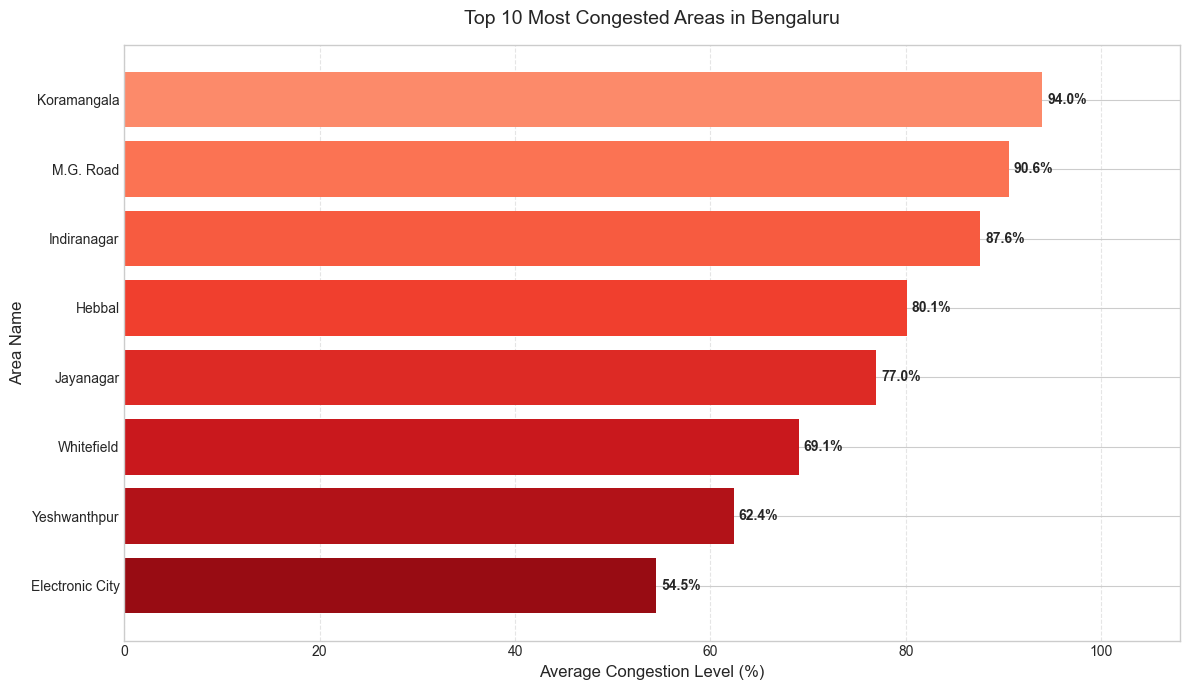

In [15]:
area_congestion = df.groupby('area_name')['congestion_level'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 7))
colors = plt.cm.Reds(np.linspace(0.4, 0.9, len(area_congestion))[::-1])
bars = plt.barh(area_congestion.index[::-1], area_congestion.values[::-1], color=colors)

for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.5, bar.get_y() + bar.get_height()/2, f'{width:.1f}%',
             va='center', ha='left', fontsize=10, fontweight='bold')

plt.title("Top 10 Most Congested Areas in Bengaluru", fontsize=14, pad=15)
plt.xlabel("Average Congestion Level (%)", fontsize=12)
plt.ylabel("Area Name", fontsize=12)
plt.xlim(0, max(area_congestion.values) * 1.15)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


### 7.6. Weather Impact Analysis on Traffic Metrics
A 2x2 grid representing how different weather conditions impact traffic volume, speed, congestion, and travel time index.


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_8672\1054518664.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0, 0].set_xticklabels(weather_grouped['weather_conditions'], rotation=45, ha='right')
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_8672\1054518664.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0, 1].set_xticklabels(weather_grouped['weather_conditions'], rotation=45, ha='right')
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_8672\1054518664.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[1, 0].set_xticklabels(weather_grouped['weather_conditions'], rotation=45, ha='right')
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_8672\1054518664.py:26: UserWarning: set_ticklabels() should only be used with a fixed number

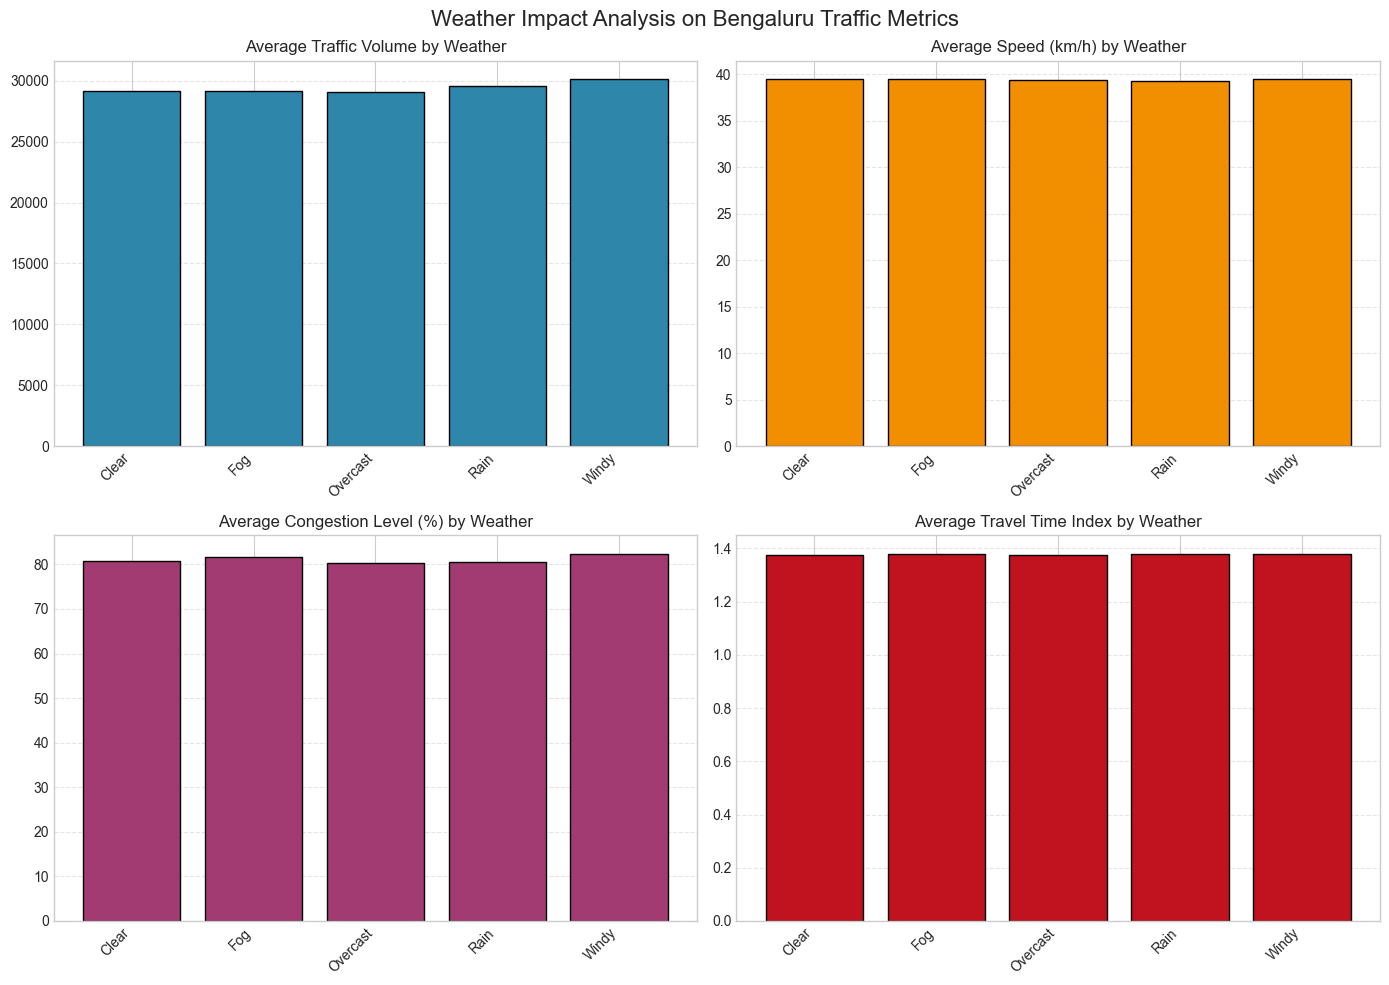

In [16]:
weather_grouped = df.groupby('weather_conditions')[['traffic_volume', 'average_speed', 'congestion_level', 'travel_time_index']].mean().reset_index()

fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# Traffic Volume
axs[0, 0].bar(weather_grouped['weather_conditions'], weather_grouped['traffic_volume'], color='#2E86AB', edgecolor='black')
axs[0, 0].set_title("Average Traffic Volume by Weather", fontsize=12)
axs[0, 0].set_xticklabels(weather_grouped['weather_conditions'], rotation=45, ha='right')
axs[0, 0].grid(axis='y', linestyle='--', alpha=0.5)

# Average Speed
axs[0, 1].bar(weather_grouped['weather_conditions'], weather_grouped['average_speed'], color='#F18F01', edgecolor='black')
axs[0, 1].set_title("Average Speed (km/h) by Weather", fontsize=12)
axs[0, 1].set_xticklabels(weather_grouped['weather_conditions'], rotation=45, ha='right')
axs[0, 1].grid(axis='y', linestyle='--', alpha=0.5)

# Congestion Level
axs[1, 0].bar(weather_grouped['weather_conditions'], weather_grouped['congestion_level'], color='#A23B72', edgecolor='black')
axs[1, 0].set_title("Average Congestion Level (%) by Weather", fontsize=12)
axs[1, 0].set_xticklabels(weather_grouped['weather_conditions'], rotation=45, ha='right')
axs[1, 0].grid(axis='y', linestyle='--', alpha=0.5)

# Travel Time Index
axs[1, 1].bar(weather_grouped['weather_conditions'], weather_grouped['travel_time_index'], color='#C1121F', edgecolor='black')
axs[1, 1].set_title("Average Travel Time Index by Weather", fontsize=12)
axs[1, 1].set_xticklabels(weather_grouped['weather_conditions'], rotation=45, ha='right')
axs[1, 1].grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle("Weather Impact Analysis on Bengaluru Traffic Metrics", fontsize=16, y=0.98)
plt.tight_layout()
plt.show()


### 7.7. Day of Week Traffic Volume (Weekday vs Weekend)
We compare weekday and weekend traffic volumes to detect commute-related trends.


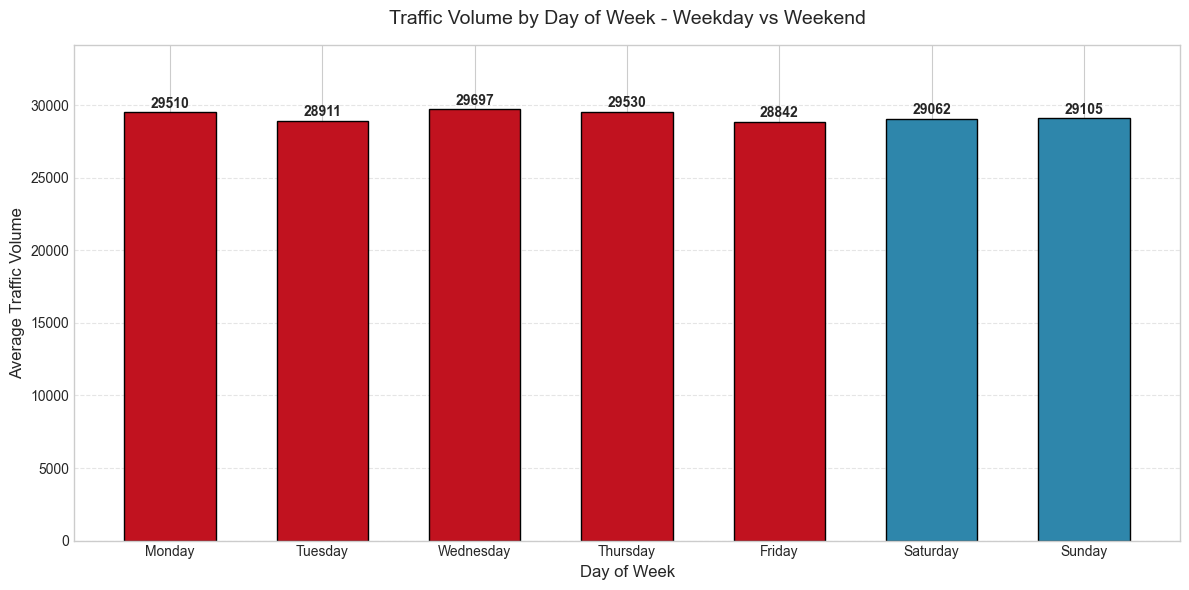

In [17]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_grouped = df.groupby('day_of_week')['traffic_volume'].mean().reindex(day_order).reset_index()

plt.figure(figsize=(12, 6))
colors = ['#C1121F' if d in ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday'] else '#2E86AB' for d in day_grouped['day_of_week']]
bars = plt.bar(day_grouped['day_of_week'], day_grouped['traffic_volume'], color=colors, edgecolor='black', width=0.6)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 100, f'{int(height)}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.title("Traffic Volume by Day of Week - Weekday vs Weekend", fontsize=14, pad=15)
plt.xlabel("Day of Week", fontsize=12)
plt.ylabel("Average Traffic Volume", fontsize=12)
plt.ylim(0, max(day_grouped['traffic_volume']) * 1.15)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## 8. Core Insights Summary
Here we compute and print the quantitative findings:


In [18]:
# Findings calculations
print("🚗 FINDING 1: PEAK TRAFFIC HOURS")
print("Hourly analysis could not be performed because the dataset only contains daily timestamps.")

# Hotspot areas
top_hotspots = df.groupby('area_name')['congestion_level'].mean().nlargest(5)
print("\n📍 FINDING 2: HOTSPOT AREAS")
for area, val in top_hotspots.items():
    print(f"- {area}: {val:.2f}%")

# Weather
df['weather_conditions_clean'] = df['weather_conditions'].str.strip().str.title()
clear_cong = df[df['weather_conditions_clean'] == 'Clear']['congestion_level'].mean()
rain_cong = df[df['weather_conditions_clean'] == 'Rain']['congestion_level'].mean()
weather_diff = ((rain_cong - clear_cong) / clear_cong) * 100
print(f"\n🌤️ FINDING 3: WEATHER IMPACT")
print(f"Clear Congestion: {clear_cong:.2f}%, Rain Congestion: {rain_cong:.2f}% (difference of {weather_diff:.2f}%)")

# Day of week
weekday_v = df[df['day_of_week'].isin(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday'])]['traffic_volume'].mean()
weekend_v = df[df['day_of_week'].isin(['Saturday', 'Sunday'])]['traffic_volume'].mean()
day_diff = ((weekday_v - weekend_v) / weekend_v) * 100
print(f"\n📅 FINDING 4: WEEKDAY vs WEEKEND")
print(f"Weekdays: {weekday_v:.1f}, Weekends: {weekend_v:.1f} (Weekdays are {day_diff:.2f}% higher)")

# Volume vs speed correlation
correlation = df['traffic_volume'].corr(df['average_speed'])
slope, intercept = np.polyfit(df['traffic_volume'], df['average_speed'], 1)
print(f"\n⚡ FINDING 5: VOLUME-SPEED RELATIONSHIP")
print(f"Correlation: {correlation:.4f}")
print(f"For every 1000 vehicles increase, speed decreases by ~{-slope*1000:.2f} km/h")


🚗 FINDING 1: PEAK TRAFFIC HOURS
Hourly analysis could not be performed because the dataset only contains daily timestamps.

📍 FINDING 2: HOTSPOT AREAS
- Koramangala: 93.99%
- M.G. Road: 90.58%
- Indiranagar: 87.64%
- Hebbal: 80.09%
- Jayanagar: 77.00%

🌤️ FINDING 3: WEATHER IMPACT
Clear Congestion: 80.72%, Rain Congestion: 80.54% (difference of -0.23%)

📅 FINDING 4: WEEKDAY vs WEEKEND
Weekdays: 29297.2, Weekends: 29084.0 (Weekdays are 0.73% higher)

⚡ FINDING 5: VOLUME-SPEED RELATIONSHIP
Correlation: -0.3411
For every 1000 vehicles increase, speed decreases by ~0.28 km/h
